Working Title: Social Media Usage and Mental Health: Can Online Habits Predict Treatment-Seeking Behavior?

Author: Navi Chawla
Course: CMPS 4790/6790 – Data Science, Tulane Universiyt
Professor: Dr. Fausty
Date: Mah rc1 h 2620

**🔗 [View this notebook on GitHub Pages](https://NaviChawla48.github.io/)**

Project Overview:
Mental health has become one of the most pressing public health issues of the 21st century, and social media usage has grown explosively over the same period. But how connected are these two trends? This tutorial investigates whether social media habits — including daily usage time, platform preferences, and self-reported effects on mood and focus — can predict whether someone seeks professional mental health treatment.

To answer this question, we combine two datasets: the OSMI Mental Health in Tech Survey (2014), which captures workplace mental health attitudes and treatment-seeking behavior among tech workers, and the Social Media & Mental Health Survey, which quantifies social media habits and their self-reported psychological effects.

Research Ques:tions
Do people who spend more time on social media report higher levels of anxiety and depression?
Can social media usage patterns and demographic features predict whether someone seeks mental health treatment?
Which social media platforms are most associated with negative mental health o
utcomes?
Why Thi:s Matters
Mental health disorders affect roughly 1 in 5 adults in the United States, yet many people never seek treatment. If social media usage patterns can serve as a reliable signal for mental health struggles, that insight could inform both public health campaigns and platform design decisions. This project sits at the intersection of behavioral science and machine learning — a genuinely useful application of data science.26

Datasets:

Dataset 1: OSMI Mental Health in Tech Survey (2014)
Source: Kaggle – OSMI Mental Health in Tech Survey
Description: A survey of ~1,260 tech industry workers about their mental health attitudes, workplace environment, and whether they have sought treatment. Key columns include Age, Gender, Country, treatment (our target variable), work_interfere, benefits, remote_work, and more.
Format: CSV, 27 col
umns
Dataset 2: Social Media & Mental Health Survey
Source: Kaggle – Social Media and Mental Health
Description: A survey of ~481 respondents about their social media habits and self-reported mental health scores. Key columns include Age, Gender, daily usage time, platforms used, and Likert-scale scores for anxiety, depression, distraction, and self-comparison.
Format: CSV (Excel-compatible), 21
 Plan for Analysis: Strategy
Both datasets share demographic fields (Age, Gender). We will aggregate the social media dataset by age group and gender to compute average mental health scores, then merge these summary statistics with the OSMI dataset. This enriches each OSMI respondent with typical social media mental health indicators for their demographic group.

Extraction, Transform, and Load (ETL)

In [1]:
#Necessary library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

#Display settings for print
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 50)
print('Libraries loaded successfully!')

Libraries loaded successfully!


Load Dataset 1: OSMI Mental Health in Tech Survey

In [2]:
#Load the OSMI Mental Health in Tech Survey
osmi_path = "/home/jovyan/notebooks/OSMI Mental Health in Tech Survey (2014).csv"
osmi_df = pd.read_csv(osmi_path)
print(f"OSMI Dataset Shape: {osmi_df.shape}")
print(f"Columns: {list(osmi_df.columns)}")
osmi_df.head()

#Check data types and missing values for sanity
print("=== OSMI Dataset Info ===")
print(osmi_df.dtypes)
print("\n=== Missing Values ===")
print(osmi_df.isnull().sum())

OSMI Dataset Shape: (1259, 27)
Columns: ['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']
=== OSMI Dataset Info ===
Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 ob

Clean Dataset 1: OSMI

The OSMI dataset has several data quality issues we need to address1. 

Age: Contains unrealistic values (negative ages, ages > 100) from bad survey entri2. es
Gender: Free-text field with hundreds of variations — we'll normalize to Male/Female/Ot3. her
Missing values: Several columns like self_employed and work_interfere have NaNs

In [3]:
#Clean Age
#Filter to realistic age range (18–75)
osmi_clean = osmi_df.copy()
osmi_clean = osmi_clean[(osmi_clean['Age'] >= 18) & (osmi_clean['Age'] <= 75)]
print(f"Rows after age filter: {len(osmi_clean)} (removed {len(osmi_df) - len(osmi_clean)} outliers)")

#Clean Gender
#Normalize the messy free-text gender field
def normalize_gender(g):
    g = str(g).strip().lower()
    if g in ['male', 'm', 'man', 'cis male', 'male (cis)', 'cis man', 'maile', 'mal', 'msle', 'mail', 'make']:
        return 'Male'
    elif g in ['female', 'f', 'woman', 'cis female', 'cis-female/femme', 'femake', 'femail', 'female (cis)', 'f']:
        return 'Female'
    else:
        return 'Other'

osmi_clean['Gender'] = osmi_clean['Gender'].apply(normalize_gender)
print("\nGender distribution after cleaning:")
print(osmi_clean['Gender'].value_counts())

#Handle Missing Values
#Fill self_employed NaN with "No" (most likely not self-employed)
osmi_clean['self_employed'] = osmi_clean['self_employed'].fillna('No')

#Fill work_interfere NaN with "Don't know"
osmi_clean['work_interfere'] = osmi_clean['work_interfere'].fillna("Don't know")

#Select what I beleive to be the most relevant columns for our analysis (can change this later if necessary)
osmi_cols = ['Age', 'Gender', 'Country', 'self_employed', 'family_history',
             'treatment', 'work_interfere', 'no_employees', 'remote_work',
             'benefits', 'seek_help', 'anonymity', 'mental_health_consequence']

osmi_clean = osmi_clean[osmi_cols].reset_index(drop=True)

#Verify dtypes for sanity
print("=== Cleaned OSMI dtypes ===")
print(osmi_clean.dtypes)
print(f"\nFinal OSMI shape: {osmi_clean.shape}")
osmi_clean.head()

Rows after age filter: 1251 (removed 8 outliers)

Gender distribution after cleaning:
Gender
Male      984
Female    247
Other      20
Name: count, dtype: int64
=== Cleaned OSMI dtypes ===
Age                           int64
Gender                       object
Country                      object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
benefits                     object
seek_help                    object
anonymity                    object
mental_health_consequence    object
dtype: object

Final OSMI shape: (1251, 13)


,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,benefits,seek_help,anonymity,mental_health_consequence
0,37,Female,United States,No,No,Yes,Often,6-25,No,Yes,Yes,Yes,No
1,44,Male,United States,No,No,No,Rarely,More than 1000,No,Don't know,Don't know,Don't know,Maybe
2,32,Male,Canada,No,No,No,Rarely,6-25,No,No,No,Don't know,No
3,31,Male,United Kingdom,No,Yes,Yes,Often,26-100,No,No,No,No,Yes
4,31,Male,United States,No,No,No,Never,100-500,Yes,Yes,Don't know,Don't know,No


Load Dataset 2: Social Media & Mental Health Survey

In [4]:
# Load the Social Media & Mental Health dataset
smmh_path = "/home/jovyan/notebooks/Social Media & Mental Health Survey.csv"
smmh_df = pd.read_csv(smmh_path)
print(f"Social Media Dataset Shape: {smmh_df.shape}")
print(f"Columns: {list(smmh_df.columns)}")
smmh_df.head()

Social Media Dataset Shape: (481, 21)
Columns: ['Timestamp', '1. What is your age?', '2. Gender', '3. Relationship Status', '4. Occupation Status', '5. What type of organizations are you affiliated with?', '6. Do you use social media?', '7. What social media platforms do you commonly use?', '8. What is the average time you spend on social media every day?', '9. How often do you find yourself using Social media without a specific purpose?', '10. How often do you get distracted by Social media when you are busy doing something?', "11. Do you feel restless if you haven't used Social media in a while?", '12. On a scale of 1 to 5, how easily distracted are you?', '13. On a scale of 1 to 5, how much are you bothered by worries?', '14. Do you find it difficult to concentrate on things?', '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?', '16. Following the previous question, how do you feel about these comparisons, generally

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,2,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,5,4,4,5,5,3,3,3,4,4,1


Clean Dataset 2: Social Media & Mental Health

In [5]:
#Rename columns to shorter, cleaner names
smmh_clean = smmh_df.copy()
#Print original columns so we can map them
for i, col in enumerate(smmh_clean.columns):
    print(f"{i}: {col}")
#Rename columns based on their position in the dataset
col_rename = {
    smmh_clean.columns[1]:  'Age',
    smmh_clean.columns[2]:  'Gender',
    smmh_clean.columns[3]:  'Relationship_Status',
    smmh_clean.columns[4]:  'Occupation',
    smmh_clean.columns[5]:  'Uses_Social_Media',
    smmh_clean.columns[6]:  'Platforms_Used',
    smmh_clean.columns[7]:  'Daily_Usage_Hours',
    smmh_clean.columns[8]:  'Uses_Without_Purpose',
    smmh_clean.columns[9]:  'Distracted_By_SM',
    smmh_clean.columns[10]: 'Restless_Without_SM',
    smmh_clean.columns[11]: 'Easily_Distracted',
    smmh_clean.columns[12]: 'Bothered_By_Worries',
    smmh_clean.columns[13]: 'Difficulty_Concentrating',
    smmh_clean.columns[14]: 'Compare_To_Others',
    smmh_clean.columns[15]: 'Feel_About_Comparisons',
    smmh_clean.columns[16]: 'Seek_Validation',
    smmh_clean.columns[17]: 'Feel_Depressed',
    smmh_clean.columns[18]: 'Fluctuating_Interest',
    smmh_clean.columns[19]: 'Sleep_Issues',
}
smmh_clean = smmh_clean.rename(columns=col_rename)

#Drop timestamp column (index 0) if present
if smmh_clean.columns[0] not in col_rename.values():
    smmh_clean = smmh_clean.drop(columns=[smmh_clean.columns[0]])
print("Renamed columns:")
print(smmh_clean.columns.tolist())
smmh_clean.head()

#Clean and normalize Gender to match OSMI
def normalize_gender_smmh(g):
    g = str(g).strip().lower()
    if 'male' in g and 'fe' not in g:
        return 'Male'
    elif 'female' in g or 'woman' in g or 'girl' in g:
        return 'Female'
    else:
        return 'Other'

smmh_clean['Gender'] = smmh_clean['Gender'].apply(normalize_gender_smmh)

#Convert Age to numeric, drop non-numeric
smmh_clean['Age'] = pd.to_numeric(smmh_clean['Age'], errors='coerce')
smmh_clean = smmh_clean.dropna(subset=['Age'])
smmh_clean['Age'] = smmh_clean['Age'].astype(int)

#Filter realistic ages
smmh_clean = smmh_clean[(smmh_clean['Age'] >= 18) & (smmh_clean['Age'] <= 75)]

#Create Age_Group column for merging
bins = [17, 24, 34, 44, 54, 75]
labels = ['18-24', '25-34', '35-44', '45-54', '55+']
smmh_clean['Age_Group'] = pd.cut(smmh_clean['Age'], bins=bins, labels=labels)
osmi_clean['Age_Group'] = pd.cut(osmi_clean['Age'], bins=bins, labels=labels)

#Ensure mental health score columns are numeric
score_cols = ['Uses_Without_Purpose', 'Distracted_By_SM', 'Restless_Without_SM',
              'Easily_Distracted', 'Bothered_By_Worries', 'Difficulty_Concentrating',
              'Compare_To_Others', 'Seek_Validation', 'Feel_Depressed',
              'Fluctuating_Interest', 'Sleep_Issues']

for col in score_cols:
    if col in smmh_clean.columns:
        smmh_clean[col] = pd.to_numeric(smmh_clean[col], errors='coerce')

print(f"Cleaned SMMH shape: {smmh_clean.shape}")
print("\nGender distribution:")
print(smmh_clean['Gender'].value_counts())
print("\nAge Group distribution:")
print(smmh_clean['Age_Group'].value_counts().sort_index())

0: Timestamp
1: 1. What is your age?
2: 2. Gender
3: 3. Relationship Status
4: 4. Occupation Status
5: 5. What type of organizations are you affiliated with?
6: 6. Do you use social media?
7: 7. What social media platforms do you commonly use?
8: 8. What is the average time you spend on social media every day?
9: 9. How often do you find yourself using Social media without a specific purpose?
10: 10. How often do you get distracted by Social media when you are busy doing something?
11: 11. Do you feel restless if you haven't used Social media in a while?
12: 12. On a scale of 1 to 5, how easily distracted are you?
13: 13. On a scale of 1 to 5, how much are you bothered by worries?
14: 14. Do you find it difficult to concentrate on things?
15: 15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?
16: 16. Following the previous question, how do you feel about these comparisons, generally speaking?
17: 17. How often do you loo

Merge the Two Datasets
Important Note: Since the two datasets are from different surveys and can't be joined row-by-row, we aggregate the social media dataset by Age Group and Gender, computing average mental health scores. These averages are then merged onto the OSMI dataset so each respondent is enriched with typical social media mental health indicators for their demographic.

In [6]:
#Aggregate SMMH by Age_Group and Gender
available_score_cols = [c for c in score_cols if c in smmh_clean.columns]
smmh_agg = smmh_clean.groupby(['Age_Group', 'Gender'])[available_score_cols].mean().round(2).reset_index()

#Rename aggregated columns to clarify they are averages
rename_agg = {col: f'avg_{col}' for col in available_score_cols}
smmh_agg = smmh_agg.rename(columns=rename_agg)
print(f"Aggregated SMMH shape: {smmh_agg.shape}")
smmh_agg.head(10)

#Merge onto OSMI dataset
merged_df = osmi_clean.merge(smmh_agg, on=['Age_Group', 'Gender'], how='left')
print(f"Merged dataset shape: {merged_df.shape}")
print(f"Rows with social media data: {merged_df['avg_Feel_Depressed'].notna().sum()}")
print(f"Rows without match: {merged_df['avg_Feel_Depressed'].isna().sum()}")
merged_df.head()

#Verify final data types for my own sanity again
print("=== Final Merged Dataset Dtypes ===")
print(merged_df.dtypes)
print(f"\nFinal shape: {merged_df.shape}")
print(f"Missing values per column:")
print(merged_df.isnull().sum())

Aggregated SMMH shape: (15, 13)
Merged dataset shape: (1251, 25)
Rows with social media data: 1236
Rows without match: 15
=== Final Merged Dataset Dtypes ===
Age                                int64
Gender                            object
Country                           object
self_employed                     object
family_history                    object
treatment                         object
work_interfere                    object
no_employees                      object
remote_work                       object
benefits                          object
seek_help                         object
anonymity                         object
mental_health_consequence         object
Age_Group                       category
avg_Uses_Without_Purpose         float64
avg_Distracted_By_SM             float64
avg_Restless_Without_SM          float64
avg_Easily_Distracted            float64
avg_Bothered_By_Worries          float64
avg_Difficulty_Concentrating     float64
avg_Compare_To_Others 

Exploratory Data Analysis (EDA)

EDA 1: Interesting Statistic: Treatment-Seeking Rate by Gender
Note: Our target variable is treatment — whether a respondent has sought professional mental health treatment.
Potential Insight: The overall treatment-seeking rate reveals whether this is a balanced or imbalanced classification problem — important for our eventual ML or Regression model. Differences by gender and age group suggest these are meaningful predictive features.

In [7]:
#Overall treatment-seeking rate
treatment_rate = osmi_clean['treatment'].value_counts(normalize=True) * 100
print("=== Overall Treatment-Seeking Rate ===")
print(treatment_rate.round(1))

#By gender
treatment_by_gender = osmi_clean.groupby('Gender')['treatment'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)
print("\n=== Treatment-Seeking Rate by Gender (%) ===")
print(treatment_by_gender)

#By age group
treatment_by_age = osmi_clean.groupby('Age_Group')['treatment'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)
print("\n=== Treatment-Seeking Rate by Age Group (%) ===")
print(treatment_by_age)

=== Overall Treatment-Seeking Rate ===
treatment
Yes    50.5
No     49.5
Name: proportion, dtype: float64

=== Treatment-Seeking Rate by Gender (%) ===
Gender
Female    68.8
Male      45.3
Other     80.0
Name: treatment, dtype: float64

=== Treatment-Seeking Rate by Age Group (%) ===
Age_Group
18-24    44.9
25-34    48.9
35-44    54.7
45-54    56.9
55+      70.6
Name: treatment, dtype: float64


EDA 2: Visualization: Treatment-Seeking vs. Average Depression Score by Age Group
Note: This chart shows, for each age group, the proportion of people seeking mental health treatment (from OSMI) alongside the average self-reported depression score from social media usage (from SMMH). If the two track together, it supports our hypothesis that social media mental health scores are predictive of treatment-seeking.
Interpretation Note: The dual-axis chart lets us visually compare two metrics from completely different surveys across the same age groups. Age groups where treatment-seeking is high AND depression scores from social media usage are high would strongly support our hypothesis that social media habits are linked to mental health treatment behavior. This chart motivates our eventual ML or Regression model.

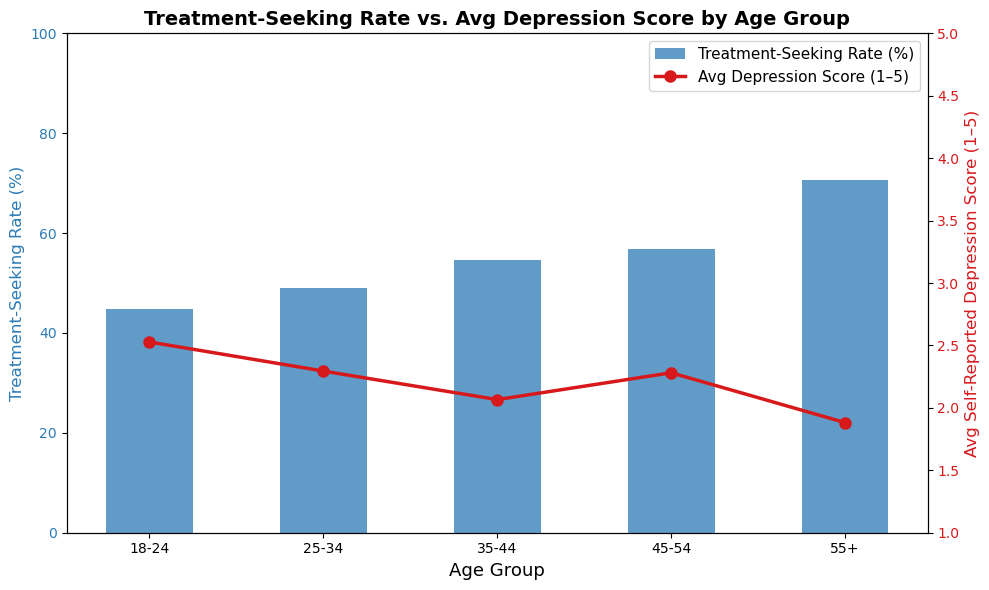

Chart saved as treatment_vs_depression_by_age.png


In [8]:
#Compute treatment rate per age group
treat_age = merged_df.groupby('Age_Group').apply(
    lambda x: (x['treatment'] == 'Yes').sum() / len(x) * 100
).reset_index()
treat_age.columns = ['Age_Group', 'Treatment_Rate']

#Compute average depression score per age group (from SMMH)
dep_age = merged_df.groupby('Age_Group')['avg_Feel_Depressed'].mean().reset_index()
dep_age.columns = ['Age_Group', 'Avg_Depression_Score']

#Merge for plotting
plot_df = treat_age.merge(dep_age, on='Age_Group').dropna()

#Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
color1 = '#2C7BB6'
color2 = '#D7191C'
bars = ax1.bar(plot_df['Age_Group'].astype(str), plot_df['Treatment_Rate'],
               color=color1, alpha=0.75, label='Treatment-Seeking Rate (%)', width=0.5)
ax1.set_xlabel('Age Group', fontsize=13)
ax1.set_ylabel('Treatment-Seeking Rate (%)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 100)
ax2 = ax1.twinx()
ax2.plot(plot_df['Age_Group'].astype(str), plot_df['Avg_Depression_Score'],
         color=color2, marker='o', linewidth=2.5, markersize=8, label='Avg Depression Score (1–5)')
ax2.set_ylabel('Avg Self-Reported Depression Score (1–5)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(1, 5)

#Combined legend (this may be wrong here)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)
plt.title('Treatment-Seeking Rate vs. Avg Depression Score by Age Group', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('treatment_vs_depression_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as treatment_vs_depression_by_age.png")

Summary:1. 
Loaded and cleaned two independent mental health dataset2. s
Normalized free-text gender fields, filtered age outliers, and handled missing valu3. es
Created a merged dataset linking OSMI workplace mental health data with aggregated social media mental health scores by demographic gr4. oup
Computed treatment-seeking rates by gender and age g5. roup
Visualized the relationship between self-reported depression scores and treatment-seeking beh
Potential avior
Cha:l1. Tenges
The OSMI gender field was a free-text entry with over 40 unique values, requiring careful normal2. ization
The two surveys cannot be merged row-by-row (different populations), so we used demographic aggregation as 3. a bridge
The social media dataset is smaller (481 rows) than OSMI (1,200), meaning aggregated scores may not perfectly represent each
Thinking/p
Plingnned Models for : 
M1. ilestone 2
Logistic Regression: Predict treatment (Yes/No) using demographic + social med2. ia features
Random Forest Classifier: Same prediction task, allowing us to extract feature importance to identify which social media behaviors are mo

Other Notes:s1. Mata Needs
We may supplement with more recent OSMI surveys (2016–2021) to improve sample s if can locateze and recency.



Export to HTML for GitHub Pages

In [9]:
!jupyter nbconvert --to html "/home/jovyan/notebooks/final project/Milestone1.ipynb" --output "/home/jovyan/notebooks/final project/index.html"

[NbConvertApp] Converting notebook /home/jovyan/notebooks/final project/Milestone1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 437143 bytes to /home/jovyan/notebooks/final project/index.html
